# **Atividade computacional: Fundamentos de Processamento de Imagens**

- Dispositivo usado: Xiaomi Note 11
- Condição de iluminação: entardecer, iluminação artificial branca
- Distância aproximada: 10cm a 2cm
- Observação de ruído: Sobras e ruídos

In [1]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
BASE_DIR = Path.cwd()
imagens_o = BASE_DIR / "data" / "letras_O&U" / "letra_o"
imagens_u = BASE_DIR / "data" / "letras_O&U" / "letra_u"

In [3]:
print(os.listdir(imagens_o))

['o1.jpg', 'o2.jpg', 'o3.jpg', 'o4.jpg', 'o5.jpg']


In [4]:
print(os.listdir(imagens_u))

['u1.jpg', 'u2.jpg', 'u3.jpg', 'u4.jpg', 'u5.jpg']


In [5]:
img_o = cv2.imread(str(f"{imagens_o}/o1.jpg"))
img_u = cv2.imread(str(f"{imagens_u}/u1.jpg"))

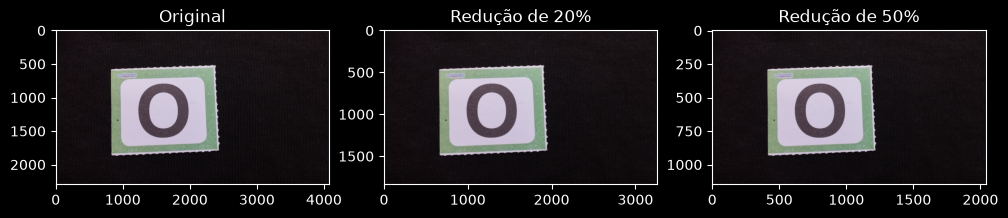

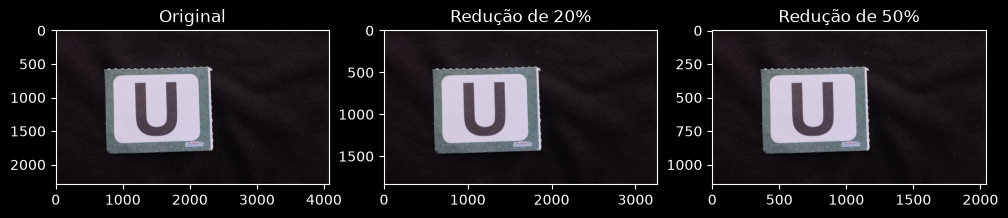

In [6]:
def analisar_resolucao(img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_50 = cv2.resize(img_rgb, (0, 0), fx=0.5, fy=0.5)
    img_20 = cv2.resize(img_rgb, (0, 0), fx=0.8, fy=0.8)

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img_rgb); axs[0].set_title('Original')
    axs[1].imshow(img_20); axs[1].set_title('Redução de 20%')
    axs[2].imshow(img_50); axs[2].set_title('Redução de 50%')
    plt.show()

analisar_resolucao(img_o)
analisar_resolucao(img_u)

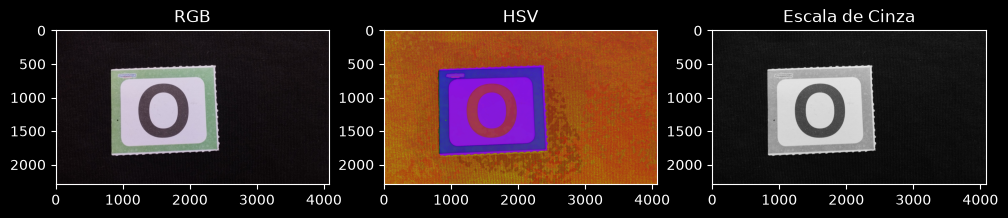

In [7]:
def espacos_de_cor(img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img_rgb); axs[0].set_title('RGB')
    axs[1].imshow(img_hsv); axs[1].set_title('HSV')
    axs[2].imshow(img_gray, cmap='gray'); axs[2].set_title('Escala de Cinza')
    plt.show()

espacos_de_cor(img_o)

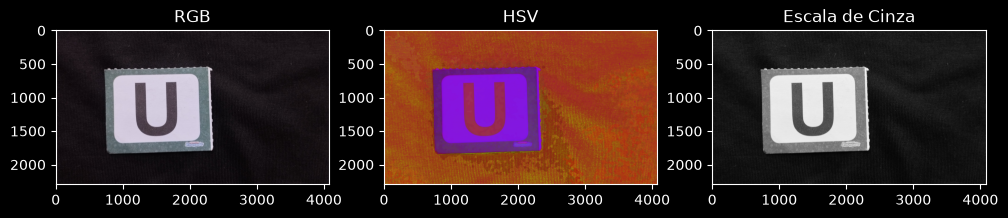

In [8]:
espacos_de_cor(img_u)

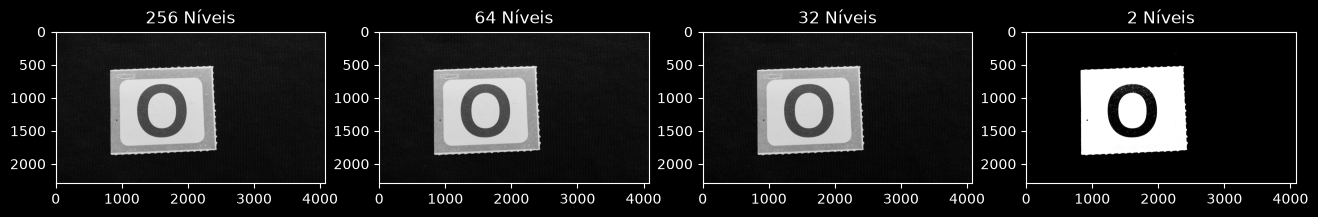

In [9]:
def quantizar_imagem(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img_64 = np.uint8((img_gray / 256) * 64) * (256 // 64)

    img_32 = np.uint8((img_gray / 256) * 32) * (256 // 32)

    _, img_2 = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    axs[0].imshow(img_gray, cmap='gray'); axs[0].set_title('256 Níveis')
    axs[1].imshow(img_64, cmap='gray'); axs[1].set_title('64 Níveis')
    axs[2].imshow(img_32, cmap='gray'); axs[2].set_title('32 Níveis')
    axs[3].imshow(img_2, cmap='gray'); axs[3].set_title('2 Níveis')
    plt.show()

quantizar_imagem(img_o)

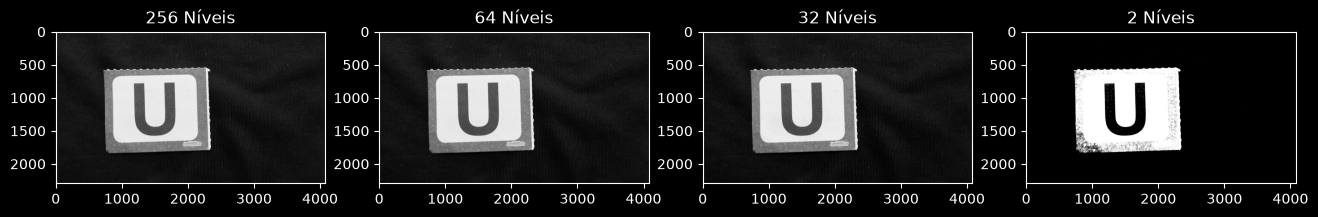

In [10]:
quantizar_imagem(img_u)

In [11]:
cv2.imwrite('letra_o_compress.jpg', img_o, [cv2.IMWRITE_JPEG_QUALITY, 10])
cv2.imwrite('letra_o_lossless.png', img_o)

tamanho_jpg = os.path.getsize('letra_o_compress.jpg') / 1024
tamanho_png = os.path.getsize('letra_o_lossless.png') / 1024

print(f"Tamanho JPEG: {tamanho_jpg:.2f} KB")
print(f"Tamanho PNG: {tamanho_png:.2f} KB")

Tamanho JPEG: 216.30 KB
Tamanho PNG: 16499.29 KB


In [12]:
cv2.imwrite('letra_u_compress.jpg', img_u, [cv2.IMWRITE_JPEG_QUALITY, 10])

tamanho_jpg = os.path.getsize('letra_u_compress.jpg') / 1024
tamanho_png = os.path.getsize('letra_u_lossless.png') / 1024

print(f"Tamanho JPEG: {tamanho_jpg:.2f} KB")
print(f"Tamanho PNG: {tamanho_png:.2f} KB")

Tamanho JPEG: 193.24 KB
Tamanho PNG: 13932.36 KB
